Starting simulation...
Simulation progress: 0.0%
Simulation progress: 10.0%
Simulation progress: 20.0%
Simulation progress: 30.0%
Simulation progress: 40.0%
Simulation progress: 50.0%
Simulation progress: 60.0%
Simulation progress: 70.0%
Simulation progress: 80.0%
Simulation progress: 90.0%
Simulation finished.


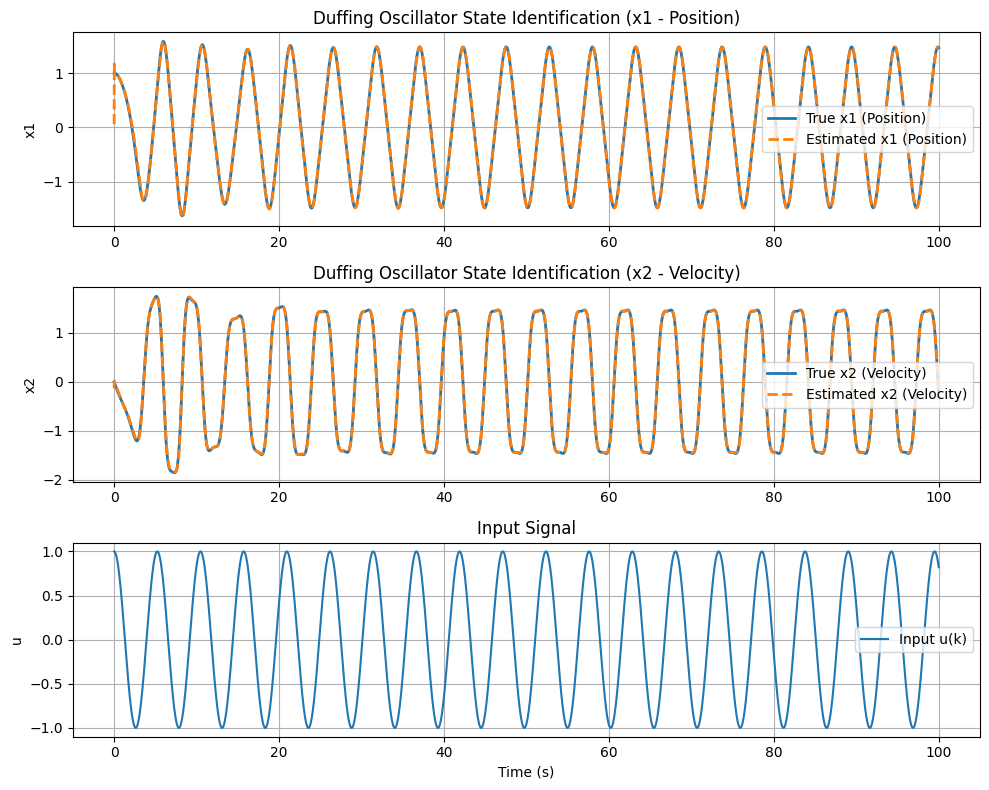

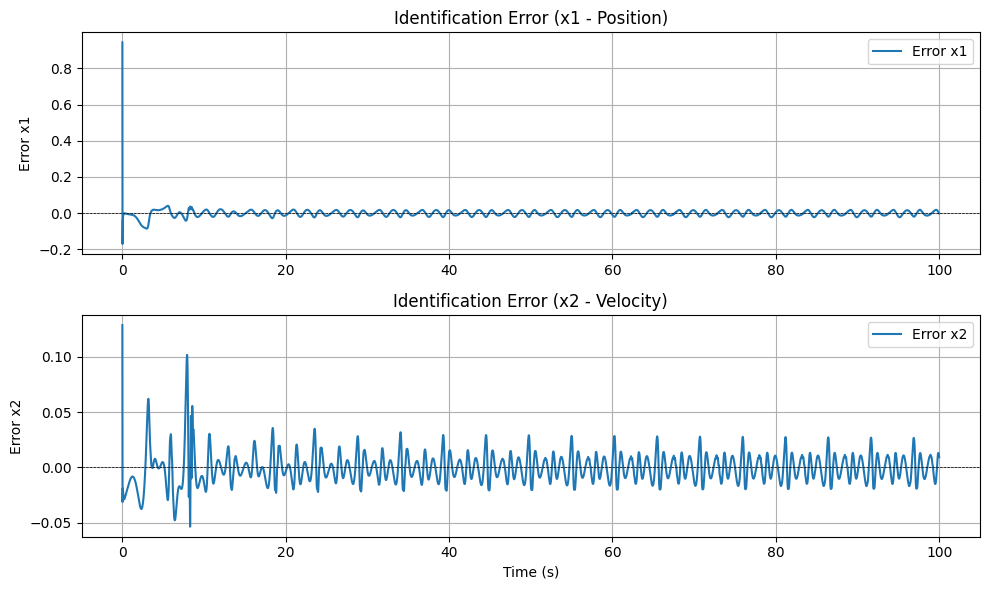


Final weights for RHONN neuron 1 (x1_dot):
[ 5.21466431 -0.01377318 -0.95818011 -0.36298349 -0.10089997  0.77386494
 -2.93736554]

Final weights for RHONN neuron 2 (x2_dot):
[-1.68357295  3.89202072  2.67223993  0.25026481 -0.17209302 -0.36822955
 -3.21649674]

RMSE x1 (Position): 0.0184
RMSE x2 (Velocity): 0.0136


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define the True Nonlinear System (Duffing Oscillator) ---
class DuffingOscillator:
    def __init__(self, alpha, beta, delta, gamma, omega, Ts):
        self.alpha = alpha
        self.beta = beta
        self.delta = delta
        self.gamma = gamma
        self.omega = omega
        self.Ts = Ts  # Sampling time
        self.x1 = 0.0 # Initial position
        self.x2 = 0.0 # Initial velocity

    def reset(self, x1_0=0.0, x2_0=0.0):
        self.x1 = x1_0
        self.x2 = x2_0

    def step(self, u_k):
        # Continuous dynamics: x1_dot = x2
        #                     x2_dot = -delta*x2 - alpha*x1 - beta*x1^3 + gamma*u
        # Euler discretization:
        x1_k = self.x1
        x2_k = self.x2
        x1_kp1 = x1_k + self.Ts * x2_k
        x2_kp1 = x2_k + self.Ts * (-self.delta * x2_k - self.alpha * x1_k - self.beta * x1_k**3 + self.gamma * u_k)
        self.x1 = x1_kp1
        self.x2 = x2_kp1
        return x1_kp1 # Output is position

# --- 2. Define the RHONN with EKF Training ---
class RHONN_EKF_Ident:
    def __init__(self, n_states, n_inputs, Li_list, beta_nn=1.0, Q_init=1e-2, R_init=1e-1, P_init=1.0):
        """
        n_states: Number of system states to identify (e.g., 2 for Duffing)
        n_inputs: Number of system inputs (e.g., 1 for Duffing)
        Li_list: List of integers, Li_list[i] = number of weights for neuron i
        beta_nn: Sigmoid steepness parameter (Eq. 5)
        Q_init, R_init, P_init: Initial noise covariances and P matrix values
        """
        self.n_states = n_states
        self.n_inputs = n_inputs
        self.beta_nn = beta_nn
        self.Li_list = Li_list # Number of weights per neuron

        # --- Initialize weights, P, Q, R for each neuron ---
        self.weights = [] # List of weight vectors for each neuron
        self.P = []       # List of P matrices for each neuron
        self.Q = []       # List of Q matrices for each neuron
        self.R = []       # List of R values for each neuron

        for i in range(n_states):
            Li = self.Li_list[i]
            # Random initial weights
            self.weights.append(np.random.randn(Li) * 0.1)
            # Initial P matrix (diagonal)
            self.P.append(np.eye(Li) * P_init)
            # Initial Q matrix (diagonal)
            self.Q.append(np.eye(Li) * Q_init)
            # Initial R value
            self.R.append(np.array([R_init]))

        self.x_hat = np.zeros(n_states) # Initial state estimate

    def sigmoid(self, x):
        # Activation function S(x) (Eq. 5, simplified beta)
        return 1.0 / (1.0 + np.exp(-self.beta_nn * x))

    def construct_z_vector(self, x_est, u):
        """
        Constructs the z vector (Eq. 3/4) for a neuron.
        Here, we use a simple structure:
        z = [S(x1), S(x2), S(u), S(x1)*S(x2), S(x1)*S(u), S(x2)*S(u), S(1)]^T
        Assumes n_states=2, n_inputs=1 for this example structure.
        """
        if self.n_states != 2 or self.n_inputs != 1:
            raise NotImplementedError("This z vector construction is for n_states=2, n_inputs=1")

        S_x1 = self.sigmoid(x_est[0])
        S_x2 = self.sigmoid(x_est[1])
        S_u = self.sigmoid(u) # Assuming scalar input
        # Higher-order terms
        S_x1_x2 = S_x1 * S_x2
        S_x1_u = S_x1 * S_u
        S_x2_u = S_x2 * S_u
        S_bias = self.sigmoid(1.0) # S(1) as a bias term

        # z vector for this specific structure
        z = np.array([S_x1, S_x2, S_u, S_x1_x2, S_x1_u, S_x2_u, S_bias])
        return z

    def predict_state(self, u_k):
        """ Predicts the next state using the current RHONN weights """
        x_hat_pred = np.zeros(self.n_states)
        for i in range(self.n_states):
            # z vector based on current state estimate and input
            # Note: For series-parallel, we ideally use measured x1 for output neuron
            # But for simplicity in this basic sim, we use the estimated x_hat
            # The paper's Eq. 6 uses chi (true/plant state) for the output term in z
            # This is a simplification for simulation
            z_i = self.construct_z_vector(self.x_hat, u_k)
            # Ensure z_i matches the expected size for weights[i]
            if len(z_i) != len(self.weights[i]):
                 raise ValueError(f"Dimension mismatch: z_i ({len(z_i)}) vs weights[{i}] ({len(self.weights[i])})")
            x_hat_pred[i] = np.dot(self.weights[i], z_i)
        return x_hat_pred

    def update_weights_and_state(self, chi_measured, u_k):
        """
        Performs one EKF step: predict state, then update weights based on measurement chi_measured.
        chi_measured: np.array of measured/true plant states [chi_1, chi_2, ...]
        u_k: Input at time k
        """
        # 1. Predict state (using current weights)
        x_hat_pred = self.predict_state(u_k)

        # 2. Update weights for each neuron using EKF
        for i in range(self.n_states):
            # Measurement for this neuron is the corresponding true state
            chi_i_measured = chi_measured[i]

            # a. Construct z vector based on predicted state (or previous estimate)
            # Paper's Eq. 11 uses x(k+1|k) for H calculation, but x(k) is often used.
            # We'll use the predicted state for constructing z for H.
            z_i = self.construct_z_vector(x_hat_pred, u_k)
            if len(z_i) != len(self.weights[i]):
                 raise ValueError(f"Dimension mismatch (update): z_i ({len(z_i)}) vs weights[{i}] ({len(self.weights[i])})")

            # b. Calculate Jacobian H_i (Eq. 11)
            # H_ij = d(x_i_pred) / d(w_ij) = z_ij
            H_i = z_i # Derivative of w^T * z w.r.t w is just z

            # c. EKF Predict step for P (Eq. 8)
            # P_i(k+1|k) = P_i(k|k) + Q_i
            P_pred = self.P[i] + self.Q[i]

            # d. Calculate innovation covariance (Eq. 9)
            # M_i = R_i + H_i^T * P_pred * H_i
            H_i = H_i.reshape(-1, 1) # Make it a column vector for matrix ops
            M_i = self.R[i][0] + np.dot(H_i.T, np.dot(P_pred, H_i))[0, 0] # M is scalar

            # e. Calculate Kalman Gain (Eq. 8)
            # K_i = P_pred * H_i / M_i
            if M_i > 1e-10: # Avoid division by zero
                K_i = np.dot(P_pred, H_i).flatten() / M_i # Flatten K back to 1D
            else:
                K_i = np.zeros_like(self.weights[i])

            # f. Calculate innovation/error (Eq. 10)
            # e_i = chi_i_measured - x_hat_pred[i]
            e_i = chi_i_measured - x_hat_pred[i]

            # g. EKF Update step for weights (Eq. 8)
            # w_i(k+1|k+1) = w_i(k+1|k) + K_i * e_i
            # Note: w(k+1|k) = w(k|k) (weights don't change in prediction unless explicitly stated)
            # So we update the stored weights directly
            self.weights[i] += K_i * e_i

            # h. EKF Update step for P (Eq. 8)
            # P_i(k+1|k+1) = P_i(k+1|k) - (K_i * H_i^T * P_i(k+1|k))
            # P_update = P_pred - np.outer(K_i, np.dot(H_i.T, P_pred)) # More general form
            # Simplified for scalar M and H as vector:
            P_update = P_pred - np.outer(K_i, np.dot(H_i.T, P_pred)).reshape(P_pred.shape)
            # Ensure P remains positive definite (basic check)
            # P_update = (P_update + P_update.T) / 2 # Symmetrize
            # A more robust approach might be needed, but this often works
            self.P[i] = P_update

        # 3. Update the internal state estimate (for next prediction)
        # In series-parallel, output state (e.g., x1) often uses the measured value
        # This helps stability. Let's assume state 0 is the output state.
        self.x_hat = np.copy(x_hat_pred) # Basic update
        # Alternative (more like paper's series-parallel concept):
        # self.x_hat[0] = chi_measured[0] # Use measured output
        # self.x_hat[1:] = x_hat_pred[1:] # Use predicted for others
        # For simplicity here, we'll stick with predicted state for internal estimate
        # The weights are the key part being adapted.

# --- 3. Simulation Parameters ---
# Duffing Oscillator Parameters
alpha_duffing = 0.5
beta_duffing = 1.0
delta_duffing = 0.3
gamma_duffing = 0.37  # Amplitude of driving force
omega_duffing = 1.2   # Frequency of driving force

# Simulation settings
Ts = 0.01  # Sampling time
t_final = 100.0
num_steps = int(t_final / Ts)

# Input signal (chirp-like or simple sinusoid)
# Following paper's idea of chirp, but simpler here
f_input = omega_duffing / (2 * np.pi)
# u(t) = gamma * cos(omega * t) -> u_k = gamma * cos(omega * k * Ts)
# But let's drive it with a different signal to see identification
# Let's use a sinusoidal input with a different frequency
f_drive = 1.0
gamma_drive = 1.0

# --- 4. Initialize System and Identifier ---
plant = DuffingOscillator(alpha_duffing, beta_duffing, delta_duffing, gamma_duffing, omega_duffing, Ts)
# Initial conditions
x1_0_true = 1.0
x2_0_true = 0.0
plant.reset(x1_0_true, x2_0_true)

# RHONN settings
n_states_plant = 2
n_inputs_plant = 1
# Number of weights for each neuron (matching the z vector size)
Li_per_neuron = 7 # [S(x1), S(x2), S(u), S(x1)*S(x2), S(x1)*S(u), S(x2)*S(u), S(1)]
Li_list_rhonn = [Li_per_neuron] * n_states_plant

# Create the RHONN identifier
identifier = RHONN_EKF_Ident(n_states_plant, n_inputs_plant, Li_list_rhonn,
                             beta_nn=1.0, Q_init=1e-4, R_init=1e-2, P_init=1.0)


# --- 5. Run Simulation ---
t_history = []
x1_true_history = []
x2_true_history = []
x1_est_history = []
x2_est_history = []
u_history = []

print("Starting simulation...")
for k in range(num_steps):
    t_k = k * Ts
    t_history.append(t_k)

    # --- 1. Generate Input ---
    # u_k = gamma_drive * np.cos(2 * np.pi * f_drive * t_k)
    # Or use the forcing term from the plant itself for consistency if desired
    u_k = np.cos(omega_duffing * t_k) # Input to the plant (part of its dynamics)
    u_history.append(u_k)

    # --- 2. Plant Step ---
    # The plant's internal dynamics use its own u (gamma*cos(omega*t))
    # But we are also applying an external u_k. Let's assume u_k is the external input
    # that drives the plant (e.g., if it were controllable). For standard Duffing,
    # the gamma*cos term is internal. Let's redefine the plant step
    # to accept an external input that adds to the forcing term.
    # For simplicity here, let's just record the plant's natural response
    # driven by its internal gamma*cos term, and use u_k as the input to the *identifier*.
    # This means the identifier sees u_k and tries to predict the plant's response.
    # The plant evolves based on its fixed parameters.
    # This is a bit different from the paper where the plant might be driven by u_k.
    # Let's stick closer to the paper: u_k is the input to both plant and identifier.
    # Redefine plant step to accept external input (add it to dynamics)
    # d2x/dt2 = ... + gamma*u_external
    # We'll modify the plant class temporarily or redefine it.
    # Simpler: redefine the step function here for clarity in this sim context.
    # Let's assume the plant's gamma is zero, and u_k is the external driving force.
    # Reset plant params for this interpretation:
    plant.gamma = gamma_drive # Use the drive amplitude for external input
    x1_k_true = plant.step(u_k) # Plant evolves with external input u_k
    x2_k_true = plant.x2 # Get the internal velocity state

    x1_true_history.append(x1_k_true)
    x2_true_history.append(x2_k_true)

    # --- 3. Identifier Prediction & Update ---
    # Get the predicted state based on current weights and input
    # x_hat_pred = identifier.predict_state(u_k) # Predicted for k+1

    # --- 4. Identifier Update (EKF) ---
    # Provide the true state measurement to the identifier for learning
    chi_measured = np.array([x1_k_true, x2_k_true])
    identifier.update_weights_and_state(chi_measured, u_k)

    # Store estimated states (predicted for next step)
    x1_est_history.append(identifier.x_hat[0])
    x2_est_history.append(identifier.x_hat[1])

    if k % (num_steps // 10) == 0:
        print(f"Simulation progress: {k/num_steps*100:.1f}%")

print("Simulation finished.")

# --- 6. Plot Results ---
fig, axs = plt.subplots(3, 1, figsize=(10, 8))

# State x1 (Position)
axs[0].plot(t_history, x1_true_history, label='True x1 (Position)', linewidth=2)
axs[0].plot(t_history, x1_est_history, '--', label='Estimated x1 (Position)', linewidth=2)
axs[0].set_ylabel('x1')
axs[0].set_title('Duffing Oscillator State Identification (x1 - Position)')
axs[0].legend()
axs[0].grid(True)

# State x2 (Velocity)
axs[1].plot(t_history, x2_true_history, label='True x2 (Velocity)', linewidth=2)
axs[1].plot(t_history, x2_est_history, '--', label='Estimated x2 (Velocity)', linewidth=2)
axs[1].set_ylabel('x2')
axs[1].set_title('Duffing Oscillator State Identification (x2 - Velocity)')
axs[1].legend()
axs[1].grid(True)

# Input
axs[2].plot(t_history, u_history, label='Input u(k)')
axs[2].set_xlabel('Time (s)')
axs[2].set_ylabel('u')
axs[2].set_title('Input Signal')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

# Plot Errors
x1_error = np.array(x1_true_history) - np.array(x1_est_history)
x2_error = np.array(x2_true_history) - np.array(x2_est_history)

fig2, axs2 = plt.subplots(2, 1, figsize=(10, 6))
axs2[0].plot(t_history, x1_error, label='Error x1')
axs2[0].set_ylabel('Error x1')
axs2[0].set_title('Identification Error (x1 - Position)')
axs2[0].legend()
axs2[0].grid(True)
axs2[0].axhline(y=0, color='k', linestyle='--', linewidth=0.5)

axs2[1].plot(t_history, x2_error, label='Error x2')
axs2[1].set_ylabel('Error x2')
axs2[1].set_xlabel('Time (s)')
axs2[1].set_title('Identification Error (x2 - Velocity)')
axs2[1].legend()
axs2[1].grid(True)
axs2[1].axhline(y=0, color='k', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# Print final weights for inspection (weights for the first neuron)
print("\nFinal weights for RHONN neuron 1 (x1_dot):")
print(identifier.weights[0])
print("\nFinal weights for RHONN neuron 2 (x2_dot):")
print(identifier.weights[1])

# Calculate and print RMSE
rmse_x1 = np.sqrt(np.mean(x1_error**2))
rmse_x2 = np.sqrt(np.mean(x2_error**2))
print(f"\nRMSE x1 (Position): {rmse_x1:.4f}")
print(f"RMSE x2 (Velocity): {rmse_x2:.4f}")
